In [ ]:
from datetime import datetime
from zoneinfo import ZoneInfo 

server_timestamp = datetime.now(ZoneInfo("New_York")).strftime("%Y-%m-%d %H:%M:%S")
print(server_timestamp)

In [ ]:
# Generating new table in sql db
import sqlite3

conn = sqlite3.connect("habits.db")
cursor = conn.cursor()
cursor.execute('''CREATE TABLE IF NOT EXISTS workouts (work_list TEXT)''')
conn.commit()
conn.close()

In [ ]:
import json
import sqlite3
# adding a list of workouts to the table
conn = sqlite3.connect("habits.db")
cursor = conn.cursor()
# intial workout list gained from original google sheets file
workouts = [
    "Biceps seated db curls",
    "Back row machine",
    "Core abdominal machine",
    "Core torso rotation machine",
    "Biceps curl machine",
    "Back ISO rear deltoid machine",
    "Chest press machine",
    "Triceps extension machine",
    "Shoulders db complex",
    "Chest pectoral fly machine",
    "Triceps db skull crushers",
    "Back pull-down machine",
    "Biceps db preacher curls",
    "Chest db bench press",
    "Leg extension machine",
    "Leg curl machine",
    "Hip abduction",
    "Hip adduction",
    "Calf leg press machine",
    "Leg press machine",
    "Biceps standing db curls",
    "Triceps pull-down",
    "Biceps curl machine high",
    "Back rear deltoid machine",
    "Chest smith machine bench",
    "Chest incline press machine",
    "Back extension machine",
    "Core complex",
    "Shoulders press machine",
    "Triceps press machine",
    "Chest push ups",
    "Hip addiction machine",
    "Calf extension machine",
    "Chest bench press",
    "Back assisted pull up machine",
    "Shoulders deltoid raise machine",
    "Trcieps pull-down",
    "other"]

workouts_json = json.dumps(workouts)

cursor.execute('''
            INSERT INTO workouts (work_list)
            VALUES (?)
        ''', (workouts_json,))
conn.commit()
conn.close()

In [ ]:
# Reading in the json from the sql db
import json
import sqlite3

conn = sqlite3.connect("habits.db")
cursor = conn.cursor()
cursor.execute("SELECT work_list FROM workouts")
result = cursor.fetchone() # only fetches one row from db

workout_list = json.loads(result[0])
print(workout_list)  # results back into list

In [ ]:
import pandas as pd
from datetime import datetime

# Assuming workouts['Timestamp'] contains strings like "10/7/2024 8:19:26"
# Format the datetime using strftime
workouts['Timestamp'] = workouts['Timestamp'].dt.strftime('%B %d, %Y %H:%M:%S')

In [ ]:
# Getting all the unqiue book titles from the habit_logs table
import json
from sqlalchemy import create_engine, text
import pandas as pd

engine = create_engine("sqlite:///habits.db")

# read_sql_query simple 
with engine.connect() as connection:
    df_filter = pd.read_sql_query(
        text("""SELECT * FROM habit_logs
             WHERE habit_type = 'reading' and 'workout'"""), connection)

engine.dispose()

# Parse JSON strings into dictionaries
df_parsed = df_filter["data"].apply(json.loads)

# Expand JSON dicts into separate columns
df_expanded = pd.json_normalize(df_parsed)

book_titles = df_expanded["book_title"].unique().tolist()

In [ ]:
# Getting all the unqiue book titles from the habit_logs table
import json
from sqlalchemy import create_engine, text
import pandas as pd

engine = create_engine("sqlite:///habits.db")

# read_sql_query simple 
with engine.connect() as connection:
    workouts = pd.read_sql_query(
        text("""SELECT exercise FROM workouts"""), connection)

engine.dispose()

workouts_list = sorted(workouts["Exercise"].unique().tolist())

In [ ]:
# Cleaning the sql db and saving it back to the same table, specifically clearing leading/trailing whitespace from the 'exercise' column

import pandas as pd
from sqlalchemy import create_engine, text

# Connect to your database
engine = create_engine("sqlite:///habits.db")  # or other dialects like postgresql://...

# Step 1: Read the table into pandas
with engine.connect() as connection:
    df = pd.read_sql_query(text("SELECT * FROM workouts"), connection)

# Step 2: Clean the data (strip leading/trailing whitespace from 'exercise' column)
df['Exercise'] = df['Exercise'].str.strip()

# Step 4: Save it back to the same table (overwrite or update)
df.to_sql("workouts", engine, if_exists="replace", index=False)

In [ ]:
import pandas as pd
from sqlalchemy import create_engine,text
import pandas as pd
import json

# Initializing the SQLite database link for the entire app
DATABASE = 'habits.db'

engine = create_engine(f"sqlite:///{DATABASE}")

# read_sql_query simple 
with engine.connect() as connection:
    whole_table = pd.read_sql_query(
        text("""SELECT * FROM habit_logs
            WHERE habit_type = 'reading'"""), connection)

# Parse JSON strings into dictionaries
df_parsed = whole_table["data"].apply(json.loads)

# Expand JSON dicts into separate columns
df_expanded = pd.json_normalize(df_parsed)

# Grtabbing unique book titles from the df and sorting them
book_titles = sorted(df_expanded["book_title"].unique().tolist())

# Add "Other" option to the list of book titles and works. This way other is not saved to the database
book_titles.append("Other")
        

#### KPI statistics for static visualization dashbaord

In [ ]:
# YTD Workouts w/ tagerts
# Grabbing monthly exercise and workout statistics for this month and last month to be displayed
import pandas as pd
from sqlalchemy import create_engine, text
import datetime as dt

def get_kpi_stats():

    # Initializing the SQLite database link
    DATABASE = 'habits.db'
    engine = create_engine(f"sqlite:///{DATABASE}")

    # Read workouts data from database
    with engine.connect() as connection:
        workout_df = pd.read_sql_query(text("SELECT * FROM workouts"), connection)

    # Ensure timestamp is in datetime format
    workout_df['Timestamp'] = pd.to_datetime(workout_df['Timestamp'])

    workout_df['month'] = workout_df['Timestamp'].dt.month_name()
    workout_df['year'] = workout_df['Timestamp'].dt.year
    workout_df['date'] = workout_df['Timestamp'].dt.date

    # Get current date and year/month details
    current_date = pd.Timestamp.now()
    current_year = current_date.year
    current_month = current_date.month

    # Calculate Year-to-Date count
    ytd_count = len(workout_df[workout_df['year'] == current_year])

    # Calculate Month-to-Date count
    mtd_count = len(workout_df[(workout_df['year'] == current_year) & 
                        (workout_df['month'] == current_date.month_name())])

    # You can also calculate previous month's total for comparison
    prev_month = current_month - 1 if current_month > 1 else 12
    year = current_year if current_month > 1 else current_year - 1

    prev_month_count = len(workout_df[(workout_df['Timestamp'].dt.year == year) & 
                                    (workout_df['Timestamp'].dt.month == prev_month)])

    # MTD Workouts w/ tagerts

    # Excersies per workout avg

    # days exercised by month
    workouts_by_month_df = workout_df.groupby(['month', 'year']).agg({'Timestamp': 'count'})

    # Days exercised by month
    days_per_month_df = workout_df.groupby(['date', 'month']).agg({'Timestamp': 'count'}).groupby(['month']).agg({'Timestamp': 'count'})

    # Format your DataFrame tables as HTML with styling
    days_per_month_html = days_per_month_df.to_html(classes='workout-table', index=True, border=0)
    workouts_by_month_html = workouts_by_month_df.to_html(classes='workout-table', index=True, border=0)

    return ytd_count, mtd_count, prev_month_count, days_per_month_html, workouts_by_month_html

ytd_count, mtd_count, prev_month_count, days_per_month_html, workouts_by_month_html = get_kpi_stats()

In [ ]:
import pandas as pd
from sqlalchemy import create_engine, text
import datetime as dt

# Initializing the SQLite database link
DATABASE = 'habits.db'
engine = create_engine(f"sqlite:///{DATABASE}")

# Read workouts data from database
with engine.connect() as connection:
    workout_df = pd.read_sql_query(text("SELECT * FROM workouts"), connection)

# Ensure timestamp is in datetime format
workout_df['Timestamp'] = pd.to_datetime(workout_df['Timestamp'])

workout_df['month'] = workout_df['Timestamp'].dt.month_name()
workout_df['year'] = workout_df['Timestamp'].dt.year
workout_df['date'] = workout_df['Timestamp'].dt.date

# Get current date and year/month details
current_date = pd.Timestamp.now()
current_year = current_date.year
current_month = current_date.month

# Calculate Year-to-Date count
ytd_count = len(workout_df[workout_df['year'] == current_year])

# Calculate Month-to-Date count
mtd_count = len(workout_df[(workout_df['year'] == current_year) & 
                        (workout_df['month'] == current_date.month_name())])


### Working on 10RM data output

In [ ]:
import pandas as pd
from sqlalchemy import create_engine, text

# Loading in workout options to then add 10RM suffix
def load_workout_options():
    engine = create_engine(f"sqlite:///habits.db")

    # read_sql_query simple 
    with engine.connect() as connection:
        workouts = pd.read_sql_query(
            text("""SELECT DISTINCT exercise FROM workouts"""), connection)

    engine.dispose()

    workouts_list = sorted(workouts["Exercise"].tolist())

    workouts = pd.DataFrame(workouts_list, columns=["Exercise"])

    return workouts

workouts = load_workout_options()

# Add the "10RM" suffix to each exercise name (observation)
workouts["Exercise"] = workouts["Exercise"] + " 10RM"

# Adding a fake temp column
workouts["weight"] = 100

# Adding spice/variation to the weight variable
workouts.loc[workouts['Exercise'].str.contains("chest", case=False, na=False), 'weight'] = 50

# Now that I have a list of 10RM workouts, I want to multiply them by the specific percentage over each week 
multipliers = {"Week 1": 0.70,
    "Week 2": 0.70,
    "Week 3": 0.75,
    "Week 4": 0.75,
    "Week 5": 0.80,
    "Week 6": 0.85,
    "Week 7": 0.90,
    "Week 8": 0.90}

# Adds suffix to row or variable names, not observations
#workouts = workouts.add_prefix("10RM")

In [ ]:
from datetime import datetime, date
import pandas as pd

t_date = date.today()

# Create a Series from today to 9 weeks (63 days) in the future
date_df = pd.DataFrame(pd.date_range(start=t_date, periods=63, freq='D'), columns= ['Date'])

date_df['Weekday'] = date_df['Date'].dt.weekday

date_df = date_df[date_df['Weekday'] == 0]  # Filter to keep only Monday

date_df['Formatted'] = date_df['Date'].dt.strftime('%b %d, %Y')

# Multipliying each workouts 10 RM by the multipliers for each week & foramtting the column names
for i, row in enumerate(multipliers.items()):
    column_name = row[0] + " " + date_df['Formatted'].iloc[i]
    workouts[column_name] = workouts["weight"] * row[1]

# Merge workout data from google sheets to sql db

In [18]:
##### WHEN READING IN UPDATED DATA FROM GOOGLE SHEET MAKE SURE TO RUN SQL COMMAND TO TRIM WHITESPACES FROM EXERCISE COLUMN ######

# Merge exisiting workouts google sheet to sql db

import pandas as pd
from sqlalchemy import create_engine
import pandas as pd
import os

sheet_id = "1TM8IcrqlYRlk8Ggxig1XMGh5e12KzZTGbh41tp6IB6k"
sheet_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv"

workouts = pd.read_csv(sheet_url)

# Ensure timestamp is in datetime format
workouts['Timestamp'] = pd.to_datetime(workouts['Timestamp'])

def df_to_sqlite(df: pd.DataFrame, name: str, db_path: str) -> None:
    # Input validation
    if not isinstance(df, pd.DataFrame):
        raise TypeError("df must be a pandas DataFrame")
    if not isinstance(name, str):
        raise TypeError("name must be a string")
    if not isinstance(db_path, str):
        raise TypeError("db_path must be a string")

    # Create a SQLite connection string
    engine = create_engine(f"sqlite:///{db_path}")

    # Save the DataFrame to the SQLite database
    df.to_sql(name=name, con=engine, if_exists='replace', index=True) # This is where index is coming from when I create the table

    # Dispose the engine
    engine.dispose()


df_to_sqlite(workouts, "workouts", "habits.db")

# Apple's health data

## Uploading/ Appending Raw apple Health data to sql db

### Inital creation of apple health data table in sql db

In [ ]:
# Creating the new table in the SQLite database (with I think appropriate data types)

import pandas as pd
from sqlalchemy import create_engine, text

# Connect to SQLite database
engine = create_engine("sqlite:///habits.db")

# Define CREATE TABLE SQL statement
create_table_sql = """
CREATE TABLE IF NOT EXISTS apple_data (
    type TEXT,
    sourceName TEXT,
    value FLOAT,
    unit TEXT,
    startDate TIMESTAMP,
    endDate TIMESTAMP,
    creationDate TIMESTAMP,
    sourceVersion TEXT,
    appleStandHours INTEGER,
    appleExerciseTimeGoal INTEGER,
    bpm INTEGER,
    maximum FLOAT,
    sum FLOAT,
    appleMoveTimeGoal INTEGER,
    average FLOAT,
    time TIMESTAMP,
    key TEXT,
    duration FLOAT,
    dateComponents TEXT,  -- SQLite doesn't support JSONB, use TEXT or JSON (in newer versions)
    CardioFitnessMedicationsUse BOOLEAN,
    activeEnergyBurned FLOAT,
    appleMoveTime INTEGER,
    date DATE,
    activeEnergyBurnedUnit TEXT,
    locale TEXT,
    appleStandHoursGoal INTEGER,
    BiologicalSex TEXT,
    FitzpatrickSkinType TEXT,
    BloodType TEXT,
    workoutActivityType TEXT,
    minimum FLOAT,
    path TEXT,
    appleExerciseTime INTEGER,
    durationUnit TEXT,
    DateOfBirth DATE,
    device TEXT,
    activeEnergyBurnedGoal INTEGER);"""

# Execute the CREATE TABLE query
with engine.connect() as connection:
    connection.execute(text(create_table_sql))

### Appending new data to existing apple workouts db

In [ ]:
# Ensure I'm only adding new data to the sql db
import pandas as pd
from sqlalchemy import create_engine, text

engine = create_engine(f"sqlite:///habits.db")

# Read from SQLite and parse those columns as datetime
with engine.connect() as connection:
    max_date_db = pd.read_sql_query(
        text("SELECT max(StartDate) FROM apple_data_raw"), 
        connection,
        parse_dates=['startDate', 'endDate', 'creationDate'])   
engine.dispose()

# Grabbing the max date from dataset to filter new data off of  
max_date_db = max_date_db['max(StartDate)'].tolist()

In [ ]:
# Read in new CSV File
apple = pd.read_csv(r"apple/apple_health_export_2025-06-22.csv")

### Cleaning Data ###

# Remove observations from csv file that are already in my sql db
apple = apple[apple["startDate"] >= max_date_db[0]]

# Fitler the source to only my Apple Watch (Could pull in other devices later like iPhone or gamin)
apple = apple[(apple['sourceName'] == "Ryan’s Apple\xa0Watch") | (apple['sourceName'].isna())]

# Strip the "HKWorkoutActivityType" prefix from the workout types
apple["workoutActivityType"] = apple["workoutActivityType"].str.replace("HKWorkoutActivityType", "")

#apple[apple["sum"].notna()]
#pple[apple["workoutActivityType"].notna()]

In [ ]:
# Convert date columns to datetime format (took 16 min to run on 2.4 million rows)
datetime_cols = ['startDate', 'endDate', 'creationDate']
for col in datetime_cols:
    apple[col] = pd.to_datetime(apple[col], errors='coerce', utc=True)

for col in datetime_cols:
    apple[col] = apple[col].dt.strftime('%Y-%m-%dT%H:%M:%S%z')

In [ ]:
# Appending the new cleaned data to my sql lite table
apple.to_sql(name="apple_data_raw", con=engine, if_exists='append', index=False)

## Clean raw apple health data and reuploading it to sql db

In [ ]:
# Read in raw apple workouts data from the sql db
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text

def Read_Apple_Workouts():
    engine = create_engine(f"sqlite:///habits.db")

    # Read from SQLite and parse those columns as datetime
    with engine.connect() as connection:
        apple = pd.read_sql_query(
            text("SELECT * FROM apple_data_raw"), 
            connection,
            parse_dates=['startDate', 'endDate', 'creationDate'])   
    engine.dispose()

    # Gather a df of workouts types, their dates, and key statistics
    # Filters df to include only rows where at least one of the workout-related columns is not missing (NaN).
    # .notna() Check for Non-Nulls in selected columns 
    # .any(axis=1) aggregates rows where there's at least one non-missing value 
    apple_workouts = apple[apple[['maximum', 'minimum', 'sum', 'average', 'duration', 'workoutActivityType', 'durationUnit']].notna().any(axis=1)] 

    # Select particular variables
    apple_workouts = apple_workouts[["workoutActivityType", "startDate", "endDate", "type", "maximum", "minimum", "sum", "average", "duration", "durationUnit"]]

    return apple_workouts

apple_workouts = Read_Apple_Workouts()

In [ ]:
# Convert apple workouts to long format
def aw_to_long(apple_workouts):

    # Reshape the apple_workouts DataFrame from wide format (one row per workout with multiple measurement columns) to long format (one row per measurement per workout).
    df_long = pd.melt(apple_workouts, 
                        id_vars=['startDate', 'endDate', 'workoutActivityType', 'type', 'duration', 'durationUnit'],
                        value_vars=['maximum', 'minimum', 'sum', 'average'], # turned into rows via where the name goes into 'measurement_type' and actual values to the 'value' column
                        var_name='measurement_type', 
                        value_name='value')

    # rRemove rows where both type and value are null (no meaningful data here)
    df_long = df_long[(df_long['type'].notna()) | (df_long['value'].notna())]

    # Handle duration rows separately and combine
    duration_rows = apple_workouts[apple_workouts['duration'].notna() & apple_workouts['type'].isna()].copy()
    duration_rows = duration_rows.assign(
        measurement_type='total',
        value=duration_rows['duration'],
        type='Duration'
    )[['startDate', 'endDate', 'workoutActivityType', 'type', 'measurement_type', 'value', 'durationUnit']]

    # Combine and clean
    result = pd.concat([df_long[df_long['value'].notna()][['startDate', 'workoutActivityType', 'type', 'measurement_type', 'value', 'durationUnit']],
        duration_rows], ignore_index=True)

    # Rename columns for clarity
    result.columns = ['StartDate', 'activity', 'metric', 'measurement_type', 'value', 'd_unit', 'EndDate']

     # cleaning value column to only go out 2 decimal places
    result['value'] = result['value'].round(2)

    result.sort_values('StartDate', ascending=False, inplace=True)

    return result

aw_long = aw_to_long(apple_workouts)

In [ ]:
# Adding activity id

def add_workout_id(aw_long):
    # Identify rows where activity is not null (these rows define the actual activity)
    activity_map = aw_long[aw_long['activity'].notnull()]

    activity_map = activity_map[["StartDate", "activity"]]

    # Creating a workout identifier
    # Creates sequential IDs starting from 0
    # Convert index IDs to integers
    activity_map = activity_map.reset_index(drop=True)
    activity_map['workout_id'] = activity_map.index

    # Merge activity back onto the main dataframe using startDate
    aw_final = aw_long.merge(activity_map, on='StartDate', how='left', suffixes=('', '_Specifier'))

    # Forward-fill the activity only for rows with the same startDate (simplicity but not needed )
    aw_final['activity'] = aw_final['activity'].fillna(aw_final['activity_Specifier'])

    # Drop helper column
    aw_final.drop(columns=['activity_Specifier'], inplace=True)

    # Think about later, can't convert column to int because of missing variables that are uploaded from garmin that wasn't filtered out initally because I need blanks
    #aw_final_new = aw_final_new['id'].astype('int')

    # Grabbing just the start of the week in dt fashion
    aw_final['week_period'] = aw_final['StartDate'].dt.to_period('W').apply(lambda r: r.start_time)

    # Adding week periods which is EXACTLY what I want! Idk why I then convert it to string
    #aw_final['week_period'] = aw_final['StartDate'].dt.to_period('W').astype(str)

    # Extract Year-Month for grouping
    aw_final['month'] = aw_final['StartDate'].dt.to_period('M')

    # Adding new activity type variable for minutes calculation 
    aw_final['activity_type'] = np.where(aw_final['activity'].isin(['Running', 'Cycling']), 'Cardio',
    np.where(aw_final['activity'] == 'TraditionalStrengthTraining', 'Weights', None))

    return aw_final

aw_final = add_workout_id(aw_long)

### Uploading aw_final to sql db

#### Inital creation of cleaned sql table

In [ ]:
# Creating the new table in the SQLite database (with I think appropriate data types)

import pandas as pd
from sqlalchemy import create_engine, text

# Connect to SQLite database
engine = create_engine("sqlite:///habits.db")

# Define new CREATE TABLE SQL statement based on your dataframe columns
create_table_sql = """CREATE TABLE IF NOT EXISTS apple_workouts (
    StartDate TIMESTAMP,
    activity TEXT,
    metric TEXT,
    measurement_type TEXT,
    value FLOAT,
    d_unit TEXT,
    EndDate TIMESTAMP,
    workout_id TEXT,
    week_period DATE,
    month TEXT,
    activity_type TEXT);"""


# Execute the CREATE TABLE query
with engine.connect() as connection:
    connection.execute(text(create_table_sql))

#### Uploading modified aw_final to the sql db

In [ ]:
# need to do a couple of string conversions before uploading the data to the sql lite db

aw_final['month'] = aw_final['month'].astype(str)
aw_final['workout_id'] = aw_final['workout_id'].astype('Int64').astype(str)
aw_final['StartDate'] = aw_final['StartDate'].dt.tz_convert(None)
aw_final['EndDate'] = aw_final['EndDate'].dt.tz_convert(None)


In [ ]:
engine = create_engine("sqlite:///habits.db")
with engine.connect() as connection:
    aw_final.to_sql(name="apple_workouts", con=engine, if_exists='append', index=False)

## Reading in clean apple health data from sql db

In [1]:
import pandas as pd
from sqlalchemy import create_engine, text

# Connect to your SQLite database
engine = create_engine("sqlite:///habits.db")

# Read in the data and parse datetime columns
with engine.connect() as connection:
    aw_final = pd.read_sql_query(
        text("SELECT * FROM apple_workouts"),
        connection,
        parse_dates=['StartDate', 'EndDate', 'week_period']
    )

# Clean up connection
engine.dispose()

# Convert 'month' to a period type for better handling of monthly data
aw_final['month'] = aw_final['month'].astype('period[M]')

## Analysis

### Tabular/Numeric Analysis

In [ ]:
# Number of unqiue activities
session_counts = aw_final[aw_final['metric'].str.contains('Duration')].groupby('activity')['StartDate'].nunique().reset_index(name='session_count')
print(session_counts)

In [ ]:
# Time I spent on each exercise every week
time_week = (
    aw_final[(aw_final['metric'] == "Duration")] # Got ride of activity filter(aw_final['activity'].isin(['Running', 'Cycling'])) 
    .groupby(['activity', 'week_period'])['value']
    .agg(Time='mean', n='count')  # compute both mean and count
    .reset_index())
time_week

In [ ]:
#Miles per week grouped by exerise 

miles_week = (aw_final[(aw_final['activity'].isin(['Running', 'Cycling'])) & (aw_final['metric'].str.contains("Distance"))]
    .groupby(['activity', 'week_period'])['value']
    .agg(Miles='mean', n='count')  # compute both mean and count
    .round(2) # Round to 2 decimal places
    .reset_index())

miles_week

### Graphical Analysis

In [7]:
# Function that fills in missing data for each grouped by df 
from itertools import product

def fill_missing_combinations(
    original_df,
    aggregated_df,
    time_col,
    category_col,
    value_cols,
    time_filter=None,
    category_values=None):

    # Step 1: Filter time periods if needed
    if time_filter:
        time_values = original_df[time_filter(original_df)].loc[:, time_col].unique()
    else:
        time_values = original_df[time_col].unique()

    # Step 2: Get all categories
    if category_values:
        category_values = category_values
    else:
        category_values = aggregated_df[category_col].unique()

    # Step 3: Create full index
    full_index = pd.DataFrame(
        product(category_values, time_values),
        columns=[category_col, time_col])

    # Step 4: Merge with aggregated data
    filled_df = pd.merge(full_index, aggregated_df, on=[category_col, time_col], how='left')

    # Step 5: Fill NaNs with 0 for specified value columns
    for col in value_cols:
        filled_df[col] = filled_df[col].fillna(0)

    return filled_df.sort_values(by=[time_col, category_col]).reset_index(drop=True)

#### Frequency bar chart grouped by exercise type 

In [15]:
# Group by month and activity, count sessions
activities = ["Walking", "Cycling", "TraditionalStrengthTraining", "Running"]

# Grab last 5 Months of data
today = pd.Timestamp.today()
l_5_m = (today - pd.DateOffset(months=5)).to_period('M')

df_counts = (aw_final[(aw_final['metric'] == 'Duration') & (aw_final['activity'].isin(activities)) & (aw_final['month'] > l_5_m)]
    .groupby(['month', 'activity'])
    .size()
    .reset_index(name='n'))

In [16]:
full_count_data = fill_missing_combinations(
    original_df=df_counts,
    aggregated_df=df_counts,
    time_col='month',
    category_col='activity',
    value_cols=['n'])

full_count_data['n'] = full_count_data['n'].astype(int)  # Convert to int for better readability

In [ ]:
# Set monthly goals per activity (you can make this dynamic)
activity_goals = {'Running': 8, 'Cycling': 8}

# Map the goal into the counts DataFrame
full_count_data['goal'] = full_count_data['activity'].map(activity_goals)

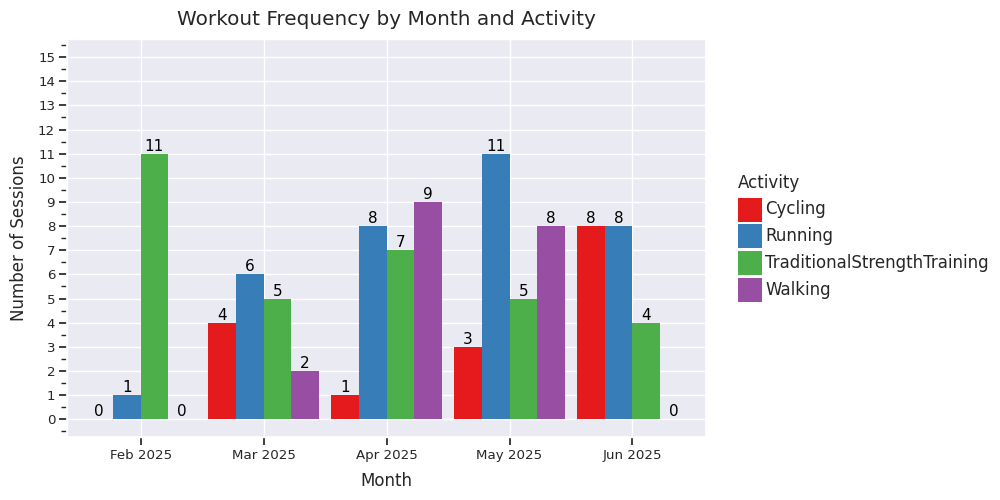

In [17]:
# Plot
from plotnine import *

plot = (ggplot(full_count_data, aes(x='month', y='n', fill='activity')) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(label='n'), position=position_dodge(width=0.9), va='bottom') + # va & ha are used for veritcal and horizontal allignment 
    #geom_hline(aes(yintercept='goal', color='activity'), linetype='dashed') +
    scale_fill_brewer(type='qual', palette='Set1') +
    #scale_color_manual(values={'Running': 'black', 'Cycling': 'gray'}) +
    scale_y_continuous(breaks = range(0, 16),
                       limits = [0, 15]) +
    scale_x_discrete(labels=lambda l: [pd.Period(p).strftime('%b %Y') for p in l]) +  #  idk how it works but it does

    labs(title='Workout Frequency by Month and Activity',
        x='Month',
        y='Number of Sessions',
        fill='Activity',
        color='Goal') +
    #theme_matplotlib() +
    theme_seaborn() +
    theme(figure_size=(10, 5)))

plot.draw()

#### Distance per week grouped by exercise type

In [ ]:
miles_week = (aw_final[(aw_final['activity'].isin(['Running', 'Cycling'])) & (aw_final['metric'].str.contains("Distance")) & (aw_final['month'] > "2025-03")]
    .groupby(['activity', 'week_period'])['value']
    .agg(Total_Miles='sum', n='count')  # compute both mean and count
    .round(2) # Round to 2 decimal places
    .reset_index())

In [ ]:
full_miles_week = fill_missing_combinations(
    original_df=aw_final,
    aggregated_df=miles_week,
    time_col='week_period',
    category_col='activity',
    value_cols=['Total_Miles', 'n'],
    time_filter=lambda df: df['month'] > "2025-03",
    category_values=['Running', 'Cycling'])

In [ ]:
# IDK how I feel about this

full_miles_week['week_label'] = full_miles_week['week_period'].dt.strftime('%b %d')
week_order = full_miles_week.sort_values('week_period')['week_label'].unique()

from pandas.api.types import CategoricalDtype
full_miles_week['week_label'] = full_miles_week['week_label'].astype(
    CategoricalDtype(categories=week_order, ordered=True))

In [ ]:
from plotnine import *

plot = (ggplot(full_miles_week, aes(x='week_label', y='Total_Miles', fill='activity')) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(label='Total_Miles'), position=position_dodge(width=0.9), va='bottom') +
    labs(title= "Miles per Week by Activity",
         x="Week",
         y="Miles") +
    theme(
        figure_size=(10, 5),
        axis_text_x=element_text(angle=20, hjust=1)))

plot

#### Time spent cardio & weight lifting per week with goals 

In [ ]:
mins_week = (aw_final[
        (aw_final['activity_type'].notna()) &
        (aw_final['metric'] == "Duration") &
        (aw_final['month'] > "2025-03")]
    .groupby(['activity_type', 'week_period'])['value']
    .agg(Total_min='sum', n='count')  # compute sum and count
    .round(2)  # Round to 2 decimal places
    .reset_index())

In [ ]:
full_mins_week = fill_missing_combinations(
    original_df=aw_final,
    aggregated_df=mins_week,
    time_col='week_period',
    category_col='activity_type',
    value_cols=['Total_min', 'n'],
    time_filter=lambda df: df['month'] > "2025-03",
    category_values=['Cardio', 'Weights'])

In [ ]:
# Goals 
# 150 minutes of moderate aerobic activity & 2 strength training exercises

In [ ]:
from plotnine import *
plot = (ggplot(full_mins_week, aes(x='week_period', y='Total_min', fill='activity_type')) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(label='Total_min'), format_string='{:.1f}', position=position_dodge(width=5), va='bottom') +

    scale_x_datetime(date_labels='%b %d', date_breaks='1 week') +  # Optional, for clean weekly ticks

    geom_hline(aes(yintercept=150, color='activity_type'), linetype='dashed', size=1) + # Cardio goal
    geom_hline(aes(yintercept=80, color='activity_type'), linetype='dashed', size=1) + # Weights goal
    
    labs(title= "Minutes per Week by Activity",
         x="Week",
         y="Minutes") +
    theme_seaborn() +
    theme(figure_size=(10, 5),
            axis_text_x = element_text(angle = 20, hjust = 1)))
plot

#### Time spent working out per week with count

In [ ]:
workout_time = aw_final[(aw_final['StartDate'].dt.year >= 2025) & 
                        (aw_final['metric'] == 'Duration')].groupby(['week_period'])['value'].agg(Time='sum', n='count').reset_index()

workout_time['Time'] = workout_time['Time'].round(2)

In [ ]:
from plotnine import *

plot = (ggplot(workout_time, aes(x='week_period', y='Time')) +
     geom_line(color = "blue", size = 1) +
     geom_point(aes(size = "n"), alpha = 0.6, color = "blue") +
    geom_text(aes(label='n'), format_string='{:.0f}', va='bottom') +
     labs(title= "Minutes per Week by Activity",
         x="Week",
         y="Minutes") +
     scale_x_datetime(date_labels='%b %d', date_breaks='1 week') +
     
    theme_seaborn() +
    theme(panel_grid_minor_y = element_line(color = "gray", linetype = "dotted"),
        figure_size=(10, 5),
        axis_text_x=element_text(angle=25, hjust=1),
        legend_position='none',
        axis_ticks_minor_x=element_blank()))
plot

#### Tree Map chart for workout distribution

In [16]:
import plotly.express as px

activites = ['Running', 'Cycling', 'TraditionalStrengthTraining', 'Swimming']

# Time I spent on each exercise every week

activity_distribution = (
    aw_final[
        (aw_final['metric'] == "Duration") & 
        (aw_final['activity'].isin(activites)) & 
        (aw_final['StartDate'].dt.year >= 2025)]
     .sort_values(by='StartDate', ascending=False)
     .head(60) # Get the last 8 weeks of data
    .groupby(['activity'])['value']
    .agg(count='count')
    .reset_index())
             
# Add percent of total column
total = activity_distribution['count'].sum()
activity_distribution['percent'] = activity_distribution['count'] / total

# Format labels as "Activity<br>Count (Percent)"
activity_distribution['label'] = activity_distribution.apply(lambda row: f"{row['activity']}<br>{row['count']} ({row['percent']:.1%})", axis=1)

In [17]:
# Create treemap
fig = px.treemap(
    activity_distribution,
    path=['label'],         # use custom label for full text
    values='count',
    color='count',
    color_continuous_scale='Blues')

fig.update_layout(showlegend=False, coloraxis_showscale=False)

# Optional: save the plot
fig.show() 

### Plotly interactive visualization

In [ ]:
def generate_plotly():
    dates = pd.date_range(end=datetime.today(), periods=30)
    habit_counts = np.random.randint(0, 5, size=30)

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=dates,
        y=habit_counts,
        mode='lines+markers',
        name='Habit Check-ins',
        line=dict(color='royalblue', width=2),
        marker=dict(size=6)
    ))
    fig.update_layout(
        title='Interactive Plot: Habit Check-ins Over 30 Days',
        xaxis_title='Date',
        yaxis_title='Check-ins',
        template='plotly_white',
        autosize=True,
        height=500
    ) 
    plotly_html = pio.to_html(fig, full_html=False)

    return plotly_html

In [ ]:
# HTML for plotly graph    
    <div class="section">
        <h2>Interactive Workout Analysis</h2>
        {{ plotly_html | safe }}
    </div>

### HTML Pandas Tables

In [ ]:
# Initializing the SQLite database link
engine = create_sql_engine()

# Read workouts data from database
with engine.connect() as connection:
    workout_df = pd.read_sql_query(text("SELECT * FROM workouts"), connection)

# Ensure timestamp is in datetime format
workout_df['Timestamp'] = pd.to_datetime(workout_df['Timestamp'])

workout_df['month'] = workout_df['Timestamp'].dt.month_name()
workout_df['year'] = workout_df['Timestamp'].dt.year
workout_df['date'] = workout_df['Timestamp'].dt.date



# days exercised by month
workouts_by_month_df = workout_df.groupby(['month', 'year']).agg({'Timestamp': 'count'})

# Days exercised by month
days_per_month_df = workout_df.groupby(['date', 'month']).agg({'Timestamp': 'count'}).groupby(['month']).agg({'Timestamp': 'count'})

# Format dfs as HTML with styling
days_per_month_html = days_per_month_df.to_html(classes='workout-table', index=True, border=0)
workouts_by_month_html = workouts_by_month_df.to_html(classes='workout-table', index=True, border=0)

In [ ]:
# HTML front end code for above 
    <!-- Table Section -->
    <div class="section flex-container">
        <div class="plot-box">
            <h2>Workouts by Month and Year</h2>
            {{ workouts_by_month_html | safe }}
        </div>
        <div class="plot-box">
            <h2>Days Exercised per Month</h2>
            {{ days_per_month_html | safe }}
        </div>
    </div>

### KPI Statistics

In [ ]:
from datetime import datetime
import pandas as pd

# Get today's date
today = pd.Timestamp.today()

# Get this month and last month as Periods
this_month = today.to_period('M')
last_month = (today - pd.DateOffset(months=1)).to_period('M')
last_month_name = (today - pd.DateOffset(months=1)).strftime('%B')

# Since I just want to get straight count numbers for this db, I can use the shape funciton
count_this_month = aw_final[(aw_final['month'] == this_month) & (aw_final['metric'] == 'Duration')].shape[0]
count_last_month = aw_final[(aw_final['month'] == last_month) & (aw_final['metric'] == 'Duration')].shape[0]
count_total_year = aw_final[(aw_final['StartDate'].dt.year >= 2025) & (aw_final['metric'] == 'Duration')].shape[0]

# Gather workout time metrics
workout_time = aw_final[(aw_final['metric'] == 'Duration')].groupby(['week_period'])['value'].agg(Time='sum', n='count').reset_index()
workout_time = workout_time.tail(5) # Taking the last 5 weeks of data 
workout_time_avg = (workout_time["Time"].mean()/60).round(2)

345.37800000000004

In [ ]:
# Gather names for above statistics
current_month = today.month
import pandas as pd

today = pd.Timestamp.today()
last_month_name = (today - pd.DateOffset(months=1)).strftime('%B')
print(last_month_name)  # e.g., "May"

## Old matlotlib and seaborn visuals

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import io
import base64

def generate_matlotlib(): 
    plt.figure(figsize=(8, 4))
    x = range(10)
    y = [i**2 for i in x]
    plt.plot(x, y, marker='o')
    plt.title('Static Plot: Squares')
    plt.xlabel('x')
    plt.ylabel('y')

    # Save static plot to bytes
    static_bytes = io.BytesIO()
    plt.savefig(static_bytes, format='png')
    static_bytes.seek(0)
    static_base64 = base64.b64encode(static_bytes.read()).decode('utf-8')
    matplotlib_plot_url = f"data:image/png;base64,{static_base64}"
    plt.close()

    return matplotlib_plot_url

def generate_seaborn():
    sns.set_theme(style="ticks", palette="pastel")

    # Load the example tips dataset
    tips = sns.load_dataset("tips")

    # Draw a nested boxplot to show bills by day and time
    plt.figure(figsize=(8, 4))  # Optional: ensure consistent sizing
    sns.boxplot(x="day", y="total_bill",
                hue="smoker", palette=["m", "g"],
                data=tips)
    sns.despine(offset=10, trim=True)

    # Save static plot to bytes
    static_bytes = io.BytesIO()
    plt.savefig(static_bytes, format='png')
    static_bytes.seek(0)
    static_base64 = base64.b64encode(static_bytes.read()).decode('utf-8')
    seaborn_plot_url = f"data:image/png;base64,{static_base64}"
    plt.close()

    return seaborn_plot_url

##### old date parsing info may be helpful

In [ ]:
df['dayofweek'] = df.index.dayofweek
#We use the map function along with a lambda function to apply the strftime method to each datetime object in the index. 
# This approach is necessary because the strftime method is designed to work with individual datetime objects, not with entire Series or DataFrames

df['dayofweekchar'] = df.index.map(lambda x: x.strftime('%A'))  # Full day name, e.g., "Monday" 
# Define the desired order of days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Convert 'day_of_week_char' to a categorical variable with the specified order
df['dayofweekchar'] = pd.Categorical(df['dayofweekchar'], categories=day_order, ordered=True)

df['quarter'] = df.index.quarter
df['month'] = df.index.month
df['month_char'] = df.index.map(lambda x: x.strftime('%b'))  # Full month name, e.g., "September"

# Define the custom order for the month names
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# Convert 'month_char' to a categorical data type with the custom order
df['month_char'] = pd.Categorical(df['month_char'], categories=month_order, ordered=True)
    # Sort the DataFrame based on the custom order

df['year'] = df.index.year

#turns it not to numeric for whatever reasosn
df['dayofyear'] = df.index.dayofyear
df['dayofyear'] = pd.to_numeric(df['dayofyear'])

df['dayofmonth'] = df.index.day
df['weekofyear'] = df.index.isocalendar().week

#### Cool XML parsing that I won't end up using ####

In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd

# Load and parse the file
tree = ET.parse('apple/export.xml') 
root = tree.getroot()

# Extract data from <Record> tags
records = []
for record in root.findall('Record'):
    records.append(record.attrib)

# Convert to DataFrame
df = pd.DataFrame(records)

#df = df[df["sourceName"] == "Ryan’s Apple Watch"]

In [ ]:
(df["type"]).unique()

In [ ]:
filtered_df = df[df["type"] == "HKQuantityTypeIdentifierPhysicalEffort"]